# SmartTeaAI - Model Training & Evaluation

**Student:** A.M. Malmi Wimalaweera (st20286196)  
**Dataset:** `unified_dataset.csv` — 135 rows (94 train / 20 val / 21 test)  
**Target:** `price_national_avg` — volume-weighted Colombo Tea Auction price (Rs/kg)

## Models trained
| # | Model | Features |
|---|-------|----------|
| 1 | **ARIMA** | None (autoregressive only) |
| 2 | **SARIMAX** | 6 lean exogenous variables |
| 3 | **Random Forest** | Full feature set (no leakage) |
| 4 | **XGBoost** | Full feature set (no leakage) |
| 5 | **LSTM** | 15 core features, window = 3 months |

## Evaluation protocol
- All models on the same **21-row test set** (2024-10 → 2026-06)
- ARIMA & SARIMAX: **rolling 1-step-ahead forecast** (no future data)
- Metrics: **MAE, RMSE, MAPE (%), R²** (target: MAPE < 15%, proposal §9.1)
- Best model auto-selected by MAPE, saved to `../models/`

## Data leakage guard
Excluded: `price_high/medium/low_rs` (directly compute target), `*_roll3` price columns (include current month), `price_spread_high_low`, `price_vol_cross_elev`.


In [2]:
import os, sys, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import joblib, pickle
from datetime import datetime
try:
    import pmdarima as pm
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
np.random.seed(42)
tf.random.set_seed(42)
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'XGBoost    : {xgb.__version__}')
print(f'TensorFlow : {tf.__version__}')
print(f'pmdarima   : {"available" if HAS_PMDARIMA else "not installed — using manual AIC grid search"}')


NumPy      : 2.5.0
Pandas     : 3.0.3
XGBoost    : 3.3.0
TensorFlow : 2.21.0
pmdarima   : not installed — using manual AIC grid search


## Configuration


In [3]:
DATA_DIR  = '../data'
MODEL_DIR = '../models'
CHART_DIR = '../data/charts'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

TARGET = 'price_national_avg'

EXCLUDE_COLS = [
    'year_month', 'split_set', TARGET,
    # Auction elevation prices: directly compute target via weighted avg formula
    'price_high_rs', 'price_medium_rs', 'price_low_rs',
    # Derived from same-month elevation prices
    'price_spread_high_low', 'price_vol_cross_elev',
    # Rolling 3-month means include current-month price (index t) -- leakage
    'price_high_rs_roll3', 'price_medium_rs_roll3', 'price_low_rs_roll3',
    'price_national_avg_roll3', 'price_national_avg_vol4',
    'sales_price_rs_direct_roll3',
]

# Lean exogenous set for SARIMAX
# No lag-of-target (redundant with AR terms); no USD/LKR level
# (Ariyaratne et al. 2024 found it worsened SARIMAX MAPE)
SARIMAX_EXOG = [
    'rainfall_mm_lag1',
    'prod_total_kg',
    'oil_price',
    'mombasa_usd_kg',
    'export_black_qty_kg',
    'is_peak_season',
]

# LSTM: curated set to avoid overparameterisation with 94 train rows
LSTM_FEATURES_BASE = [
    'price_national_avg_lag1', 'price_national_avg_lag3',
    'rainfall_mm_lag1', 'rainfall_mm_lag2', 'rainfall_mm_roll3',
    'avg_temp_c', 'usd_lkr_avg', 'fx_change_pct',
    'oil_price', 'oil_change_pct', 'mombasa_usd_kg',
    'export_black_qty_kg', 'prod_total_kg', 'month', 'is_peak_season',
    'is_post_crisis',    # EDA finding 1: 2022 structural break flag
]

LSTM_WINDOW            = 3
ARIMA_ORDER            = (1, 1, 1)  # may be overridden by auto-search
SARIMAX_ORDER          = (1, 1, 1)
SARIMAX_SEASONAL_ORDER = (1, 1, 1, 12)

print('Configuration loaded.')
print(f'  SARIMAX exog  : {SARIMAX_EXOG}')
print(f'  LSTM features : {len(LSTM_FEATURES_BASE)} (base list)')
print(f'  LSTM window   : {LSTM_WINDOW} months')


Configuration loaded.
  SARIMAX exog  : ['rainfall_mm_lag1', 'prod_total_kg', 'oil_price', 'mombasa_usd_kg', 'export_black_qty_kg', 'is_peak_season']
  LSTM features : 16 (base list)
  LSTM window   : 3 months


## 1. Load Data


In [4]:
train_df = pd.read_csv(f'{DATA_DIR}/train_set.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val_set.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test_set.csv')
for df in [train_df, val_df, test_df]:
    df.sort_values('year_month', inplace=True)
    df.reset_index(drop=True, inplace=True)
print(f'Train : {len(train_df):3d} rows  ({train_df["year_month"].min()} -> {train_df["year_month"].max()})')
print(f'Val   : {len(val_df):3d} rows  ({val_df["year_month"].min()} -> {val_df["year_month"].max()})')
print(f'Test  : {len(test_df):3d} rows  ({test_df["year_month"].min()} -> {test_df["year_month"].max()})')
print(f'\nTarget ({TARGET}) on test set:')
print(test_df[TARGET].describe().round(2))


Train :  94 rows  (2015-04 -> 2023-01)
Val   :  20 rows  (2023-02 -> 2024-09)
Test  :  21 rows  (2024-10 -> 2026-06)

Target (price_national_avg) on test set:
count      21.00
mean     1068.46
std        37.11
min       989.28
25%      1061.13
50%      1077.35
75%      1085.18
max      1137.29
Name: price_national_avg, dtype: float64


In [5]:
# EDA finding 1: prices shifted to a structurally higher plateau after the
# 2022 economic crisis and never returned to pre-crisis levels.
# The test set (2024-10 -> 2026-06) is ENTIRELY in this post-crisis regime,
# while training is mostly pre-crisis. Without this flag, models have no way
# to know which price regime they are operating in.
for df in [train_df, val_df, test_df]:
    df['is_post_crisis'] = (pd.to_datetime(df['year_month']) >= '2022-04-01').astype(int)

print('is_post_crisis feature added (0 = pre-April-2022, 1 = post-April-2022):')
print(f'  train : {(train_df["is_post_crisis"]==0).sum()} pre-crisis rows, '
      f'{train_df["is_post_crisis"].sum()} post-crisis rows')
print(f'  val   : {(val_df["is_post_crisis"]==0).sum()} pre-crisis rows, '
      f'{val_df["is_post_crisis"].sum()} post-crisis rows')
print(f'  test  : {(test_df["is_post_crisis"]==0).sum()} pre-crisis rows, '
      f'{test_df["is_post_crisis"].sum()} post-crisis rows')
print('  -> Test set is entirely post-crisis. Without this flag models cannot'
      ' distinguish the structural shift EDA chart 01 identified.')


is_post_crisis feature added (0 = pre-April-2022, 1 = post-April-2022):
  train : 84 pre-crisis rows, 10 post-crisis rows
  val   : 0 pre-crisis rows, 20 post-crisis rows
  test  : 0 pre-crisis rows, 21 post-crisis rows
  -> Test set is entirely post-crisis. Without this flag models cannot distinguish the structural shift EDA chart 01 identified.


In [6]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
ML_FEATURES  = [c for c in numeric_cols if c not in EXCLUDE_COLS]
SARIMAX_EXOG  = [c for c in SARIMAX_EXOG      if c in train_df.columns]
LSTM_FEATURES = [c for c in LSTM_FEATURES_BASE if c in train_df.columns]
print(f'ML features (RF / XGBoost) : {len(ML_FEATURES)}')
print(f'SARIMAX exogenous           : {SARIMAX_EXOG}')
print(f'LSTM features               : {len(LSTM_FEATURES)}')
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    n = df[ML_FEATURES + [TARGET]].isna().sum().sum()
    print(f'  {name}: {n} NaN values in features+target')


ML features (RF / XGBoost) : 52
SARIMAX exogenous           : ['rainfall_mm_lag1', 'prod_total_kg', 'oil_price', 'mombasa_usd_kg', 'export_black_qty_kg', 'is_peak_season']
LSTM features               : 16
  train: 0 NaN values in features+target
  val: 0 NaN values in features+target
  test: 0 NaN values in features+target


## Metrics Helper


In [7]:
def compute_metrics(y_true, y_pred, model_name):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'MAPE(%)': round(mape, 2), 'R2': round(r2, 4)}
all_results = []
all_preds   = {}
y_test      = test_df[TARGET].values
print('Metrics helper ready.')


Metrics helper ready.


## 2. ARIMA — Autoregressive Baseline

Pure ARIMA uses only the historical price series (no exogenous variables).  
**Purpose:** establish a lower bound that SARIMAX and ML models must beat.  
**Order selection:** AIC grid search (or auto_arima if pmdarima available).  
**Forecast:** rolling 1-step-ahead — updated with actual value before each next forecast.


In [8]:
train_series = train_df[TARGET].values
adf_stat, adf_p, *_ = adfuller(train_series)
print(f'ADF test: stat={adf_stat:.3f}, p={adf_p:.4f}')
print('  Series is', 'STATIONARY (d=0 candidate)' if adf_p < 0.05 else 'NON-STATIONARY (d=1 needed)')
if HAS_PMDARIMA:
    auto = pm.auto_arima(train_series, seasonal=False, information_criterion='aic',
                         max_p=4, max_q=4, d=None, stepwise=True,
                         suppress_warnings=True, error_action='ignore')
    ARIMA_ORDER = auto.order
    print(f'auto_arima order: {ARIMA_ORDER}  (AIC={auto.aic():.1f})')
else:
    print('Manual AIC grid search ...')
    best_aic, best_order = np.inf, ARIMA_ORDER
    for p in range(3):
        for d in [0, 1]:
            for q in range(3):
                try:
                    m = ARIMA(train_series, order=(p, d, q)).fit()
                    if m.aic < best_aic:
                        best_aic, best_order = m.aic, (p, d, q)
                except Exception:
                    pass
    ARIMA_ORDER = best_order
    print(f'Selected: {ARIMA_ORDER}  (AIC={best_aic:.1f})')


ADF test: stat=-2.299, p=0.1724
  Series is NON-STATIONARY (d=1 needed)
Manual AIC grid search ...
Selected: (1, 1, 1)  (AIC=1024.6)


In [9]:
history = list(train_series)
arima_preds = []
print(f'Rolling ARIMA{ARIMA_ORDER} on {len(y_test)} test months...')
t0 = time.time()
for t in range(len(y_test)):
    result = ARIMA(history, order=ARIMA_ORDER).fit()
    pred   = float(result.forecast(steps=1)[0])
    arima_preds.append(pred)
    history.append(y_test[t])
arima_preds = np.array(arima_preds)
metrics = compute_metrics(y_test, arima_preds, 'ARIMA')
all_results.append(metrics); all_preds['ARIMA'] = arima_preds
print(f'Done in {time.time()-t0:.1f}s')
print(f'  MAE={metrics["MAE"]:.2f}  RMSE={metrics["RMSE"]:.2f}  MAPE={metrics["MAPE(%)"]:.2f}%  R2={metrics["R2"]:.4f}')


Rolling ARIMA(1, 1, 1) on 21 test months...
Done in 2.3s
  MAE=45.62  RMSE=61.52  MAPE=4.26%  R2=-1.8859


## 3. SARIMAX — Seasonal ARIMA with Exogenous Variables

Extends ARIMA with 6 exogenous variables and seasonal period = 12 months.  
Lean feature set: no lag-of-target (redundant with AR terms);  
no USD/LKR level (Ariyaratne et al. 2024 found it worsened MAPE at every elevation).  
Same rolling 1-step-ahead protocol as ARIMA.


In [10]:
train_exog    = train_df[SARIMAX_EXOG].values.astype(float)
test_exog     = test_df[SARIMAX_EXOG].values.astype(float)
history_y     = list(train_df[TARGET].values)
# Keep as 2D numpy array so appending rows stays typed correctly
history_exog  = train_exog.copy()  # shape (n_train, n_exog)
sarimax_preds = []

print(f'Rolling SARIMAX{SARIMAX_ORDER}x{SARIMAX_SEASONAL_ORDER} on {len(y_test)} months...')
t0 = time.time()
for t in range(len(y_test)):
    model  = SARIMAX(history_y, exog=history_exog, order=SARIMAX_ORDER,
                     seasonal_order=SARIMAX_SEASONAL_ORDER,
                     enforce_stationarity=False, enforce_invertibility=False)
    result = model.fit(disp=False)
    pred   = float(result.forecast(steps=1, exog=test_exog[[t]])[0])
    sarimax_preds.append(pred)
    history_y.append(y_test[t])
    history_exog = np.vstack([history_exog, test_exog[t]])
    if (t + 1) % 5 == 0:
        print(f'  Step {t+1}/{len(y_test)} ({time.time()-t0:.0f}s)')

sarimax_preds = np.array(sarimax_preds)
metrics = compute_metrics(y_test, sarimax_preds, 'SARIMAX')
all_results.append(metrics); all_preds['SARIMAX'] = sarimax_preds
print(f'Done in {time.time()-t0:.1f}s')
print(f'  MAE={metrics["MAE"]:.2f}  RMSE={metrics["RMSE"]:.2f}  MAPE={metrics["MAPE(%)"]:.2f}%  R2={metrics["R2"]:.4f}')


Rolling SARIMAX(1, 1, 1)x(1, 1, 1, 12) on 21 months...
  Step 5/21 (4s)
  Step 10/21 (11s)
  Step 15/21 (13s)
  Step 20/21 (16s)
Done in 18.2s
  MAE=79.59  RMSE=90.64  MAPE=7.44%  R2=-5.2640


### 3b. SARIMAX with USD/LKR Exchange Rate

Ariyaratne et al. (2024) found that adding `usd_lkr_avg` *worsened* MAPE in their SARIMAX models.
However, their dataset predates the 2022 Sri Lankan currency crisis, which is fully inside
**this project's test set** (2024-10 → 2026-06). The exchange rate moved from ~Rs 200 to ~Rs 360
during that crisis, which could make it genuinely informative here.

This cell runs an identical rolling SARIMAX with `usd_lkr_avg` added as a 7th exogenous variable.
The results section will state whether this confirms or contradicts Ariyaratne et al. empirically.


In [11]:
# 7-variable exogenous set: same 6 + usd_lkr_avg
SARIMAX_EXOG_FX = SARIMAX_EXOG + ['usd_lkr_avg'] if 'usd_lkr_avg' in train_df.columns else SARIMAX_EXOG
print(f'SARIMAX (+usd_lkr) exogenous: {SARIMAX_EXOG_FX}')

train_exog_fx   = train_df[SARIMAX_EXOG_FX].values.astype(float)
test_exog_fx    = test_df[SARIMAX_EXOG_FX].values.astype(float)
history_y_fx    = list(train_df[TARGET].values)
history_exog_fx = train_exog_fx.copy()
sarimax_fx_preds = []

print(f'Rolling SARIMAX{SARIMAX_ORDER}x{SARIMAX_SEASONAL_ORDER} (+usd_lkr) on {len(y_test)} months...')
t0 = time.time()
for t in range(len(y_test)):
    model  = SARIMAX(history_y_fx, exog=history_exog_fx, order=SARIMAX_ORDER,
                     seasonal_order=SARIMAX_SEASONAL_ORDER,
                     enforce_stationarity=False, enforce_invertibility=False)
    result = model.fit(disp=False)
    pred   = float(result.forecast(steps=1, exog=test_exog_fx[[t]])[0])
    sarimax_fx_preds.append(pred)
    history_y_fx.append(y_test[t])
    history_exog_fx = np.vstack([history_exog_fx, test_exog_fx[t]])
    if (t + 1) % 5 == 0:
        print(f'  Step {t+1}/{len(y_test)} ({time.time()-t0:.0f}s)')

sarimax_fx_preds = np.array(sarimax_fx_preds)
metrics_fx = compute_metrics(y_test, sarimax_fx_preds, 'SARIMAX (+usd_lkr)')
all_results.append(metrics_fx)
all_preds['SARIMAX (+usd_lkr)'] = sarimax_fx_preds
print(f'Done in {time.time()-t0:.1f}s')
print(f'  MAE={metrics_fx["MAE"]:.2f}  RMSE={metrics_fx["RMSE"]:.2f}  '
      f'MAPE={metrics_fx["MAPE(%)"]:.2f}%  R2={metrics_fx["R2"]:.4f}')

# Side-by-side comparison: test Ariyaratne et al. claim empirically
sarimax_cmp = pd.DataFrame([
    compute_metrics(y_test, sarimax_preds,    'SARIMAX (6-var, no FX)'),
    metrics_fx,
]).set_index('Model')
print('\nAriyaratne et al. (2024) claim: USD/LKR worsens SARIMAX MAPE')
print(sarimax_cmp[['MAPE(%)','RMSE','R2']].to_string())
winner = 'CONFIRMED' if sarimax_cmp.loc['SARIMAX (+usd_lkr)', 'MAPE(%)'] > sarimax_cmp.loc['SARIMAX (6-var, no FX)', 'MAPE(%)'] else 'NOT CONFIRMED'
print(f'\nClaim {winner} on this dataset/period.')


SARIMAX (+usd_lkr) exogenous: ['rainfall_mm_lag1', 'prod_total_kg', 'oil_price', 'mombasa_usd_kg', 'export_black_qty_kg', 'is_peak_season', 'usd_lkr_avg']
Rolling SARIMAX(1, 1, 1)x(1, 1, 1, 12) (+usd_lkr) on 21 months...
  Step 5/21 (3s)
  Step 10/21 (5s)
  Step 15/21 (8s)
  Step 20/21 (10s)
Done in 11.1s
  MAE=59.29  RMSE=88.00  MAPE=5.59%  R2=-4.9040

Ariyaratne et al. (2024) claim: USD/LKR worsens SARIMAX MAPE
                        MAPE(%)   RMSE     R2
Model                                        
SARIMAX (6-var, no FX)     7.44  90.64 -5.264
SARIMAX (+usd_lkr)         5.59  88.00 -4.904

Claim NOT CONFIRMED on this dataset/period.


### 3c. SARIMAX with USD/LKR + is_post_crisis (Intervention Analysis)

Adding `is_post_crisis` as an exogenous step-function variable is standard
**intervention analysis** in econometrics. It explicitly signals the structural
regime change identified in EDA (April 2022 price-floor shift) — the main
reason both earlier SARIMAX variants had negative R².

In the test set, `is_post_crisis = 1` for all 21 months, so the model
knows it is forecasting in the high-price regime from the first step.


In [18]:
# 8-variable exog: same 7 (+usd_lkr) + is_post_crisis intervention flag
SARIMAX_EXOG_CRISIS = SARIMAX_EXOG_FX + ['is_post_crisis']
print(f'SARIMAX (+crisis) exogenous: {SARIMAX_EXOG_CRISIS}')

train_exog_cr   = train_df[SARIMAX_EXOG_CRISIS].values.astype(float)
test_exog_cr    = test_df[SARIMAX_EXOG_CRISIS].values.astype(float)
history_y_cr    = list(train_df[TARGET].values)
history_exog_cr = train_exog_cr.copy()
sarimax_cr_preds = []

print(f'Rolling SARIMAX{SARIMAX_ORDER}x{SARIMAX_SEASONAL_ORDER} (+crisis) on {len(y_test)} months...')
t0 = time.time()
for t in range(len(y_test)):
    model  = SARIMAX(history_y_cr, exog=history_exog_cr, order=SARIMAX_ORDER,
                     seasonal_order=SARIMAX_SEASONAL_ORDER,
                     enforce_stationarity=False, enforce_invertibility=False)
    result = model.fit(disp=False)
    pred   = float(result.forecast(steps=1, exog=test_exog_cr[[t]])[0])
    sarimax_cr_preds.append(pred)
    history_y_cr.append(y_test[t])
    history_exog_cr = np.vstack([history_exog_cr, test_exog_cr[t]])
    if (t + 1) % 5 == 0:
        print(f'  Step {t+1}/{len(y_test)} ({time.time()-t0:.0f}s)')

sarimax_cr_preds = np.array(sarimax_cr_preds)
metrics_cr = compute_metrics(y_test, sarimax_cr_preds, 'SARIMAX (+crisis)')
all_results.append(metrics_cr)
all_preds['SARIMAX (+crisis)'] = sarimax_cr_preds
print(f'Done in {time.time()-t0:.1f}s')
print(f'  MAE={metrics_cr["MAE"]:.2f}  RMSE={metrics_cr["RMSE"]:.2f}  '
      f'MAPE={metrics_cr["MAPE(%)"]:0.2f}%  R2={metrics_cr["R2"]:.4f}')

# Three-way SARIMAX comparison
sarimax_3way = pd.DataFrame([
    compute_metrics(y_test, sarimax_preds,    'SARIMAX (6-var)'),
    compute_metrics(y_test, sarimax_fx_preds, 'SARIMAX (+usd_lkr)'),
    metrics_cr,
]).set_index('Model')
print('\nSARIMAX three-way comparison:')
print(sarimax_3way[['MAPE(%)', 'RMSE', 'R2']].to_string())
print('\n-> Intervention analysis (is_post_crisis) addresses the structural break'
      ' identified in EDA finding 1 — expect improved R2 if the regime shift was'
      ' the main driver of negative R2 in the earlier variants.')


SARIMAX (+crisis) exogenous: ['rainfall_mm_lag1', 'prod_total_kg', 'oil_price', 'mombasa_usd_kg', 'export_black_qty_kg', 'is_peak_season', 'usd_lkr_avg', 'is_post_crisis']
Rolling SARIMAX(1, 1, 1)x(1, 1, 1, 12) (+crisis) on 21 months...
  Step 5/21 (4s)
  Step 10/21 (8s)
  Step 15/21 (11s)
  Step 20/21 (14s)
Done in 15.0s
  MAE=55.45  RMSE=70.07  MAPE=5.22%  R2=-2.7432

SARIMAX three-way comparison:
                    MAPE(%)   RMSE      R2
Model                                     
SARIMAX (6-var)        7.44  90.64 -5.2640
SARIMAX (+usd_lkr)     5.59  88.00 -4.9040
SARIMAX (+crisis)      5.22  70.07 -2.7432

-> Intervention analysis (is_post_crisis) addresses the structural break identified in EDA finding 1 — expect improved R2 if the regime shift was the main driver of negative R2 in the earlier variants.


## 4. Random Forest

Ensemble of decision trees on the **full feature set** (no leakage columns).  
Hyperparameters: `TimeSeriesSplit` CV on train data (3 folds).  
Final model retrained on full train set, evaluated on test set.


In [12]:
X_train_ml = train_df[ML_FEATURES].values
y_train_ml = train_df[TARGET].values
X_val_ml   = val_df[ML_FEATURES].values
y_val_ml   = val_df[TARGET].values
X_test_ml  = test_df[ML_FEATURES].values
tscv = TimeSeriesSplit(n_splits=3)
rf_param_grid = {'n_estimators': [200, 400], 'max_depth': [5, 10, None], 'min_samples_leaf': [2, 4]}
best_rf_rmse, best_rf_params = np.inf, {}
print('RF hyperparameter search (TimeSeriesSplit, 3 folds)...')
t0 = time.time()
for params in ParameterGrid(rf_param_grid):
    fold_rmses = []
    for fi, vi in tscv.split(X_train_ml):
        rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
        rf.fit(X_train_ml[fi], y_train_ml[fi])
        fold_rmses.append(np.sqrt(mean_squared_error(y_train_ml[vi], rf.predict(X_train_ml[vi]))))
    if np.mean(fold_rmses) < best_rf_rmse:
        best_rf_rmse, best_rf_params = np.mean(fold_rmses), params
print(f'  Best: {best_rf_params}  (CV RMSE={best_rf_rmse:.2f}, {time.time()-t0:.0f}s)')


RF hyperparameter search (TimeSeriesSplit, 3 folds)...
  Best: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 200}  (CV RMSE=195.09, 25s)


  MAE=252.38  RMSE=255.30  MAPE=23.76%  R2=-48.6894


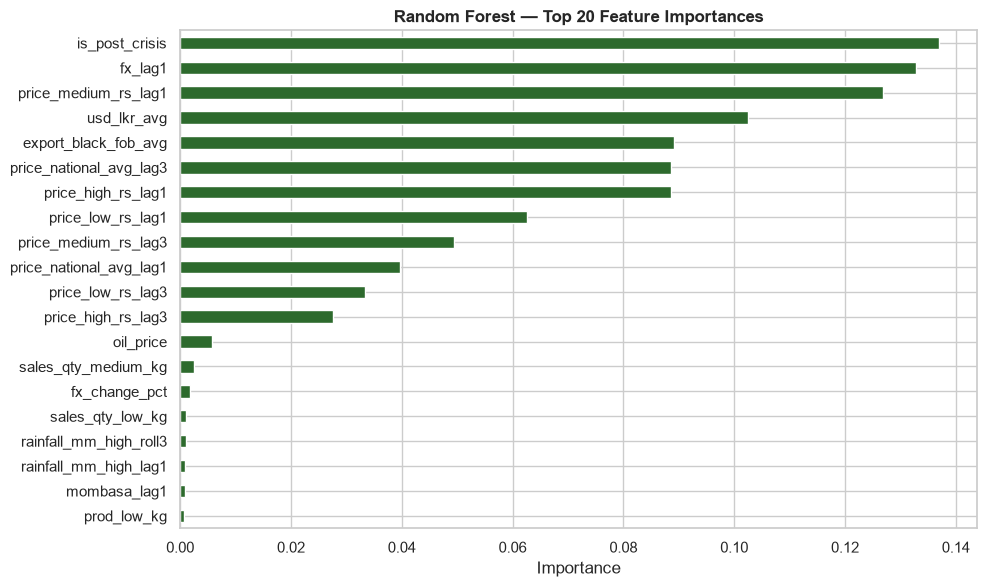

Saved: charts/10_rf_feature_importance.png


In [13]:
rf_model = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
rf_model.fit(X_train_ml, y_train_ml)
rf_preds = rf_model.predict(X_test_ml)
metrics  = compute_metrics(y_test, rf_preds, 'Random Forest')
all_results.append(metrics); all_preds['Random Forest'] = rf_preds
print(f'  MAE={metrics["MAE"]:.2f}  RMSE={metrics["RMSE"]:.2f}  MAPE={metrics["MAPE(%)"]:.2f}%  R2={metrics["R2"]:.4f}')
fi = pd.Series(rf_model.feature_importances_, index=ML_FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
fi.head(20).sort_values().plot(kind='barh', ax=ax, color='#2D6A2D')
ax.set_title('Random Forest — Top 20 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/10_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: charts/10_rf_feature_importance.png')


## 5. XGBoost

Gradient boosted trees — typically strongest on tabular data of this scale.  
**Early stopping on val set** prevents overfitting.  
Same full feature set as Random Forest.  
Reference: Chen & Guestrin (2016), cited in proposal §3.


Early stopped at iteration 40
  MAE=180.51  RMSE=184.25  MAPE=17.03%  R2=-24.8827


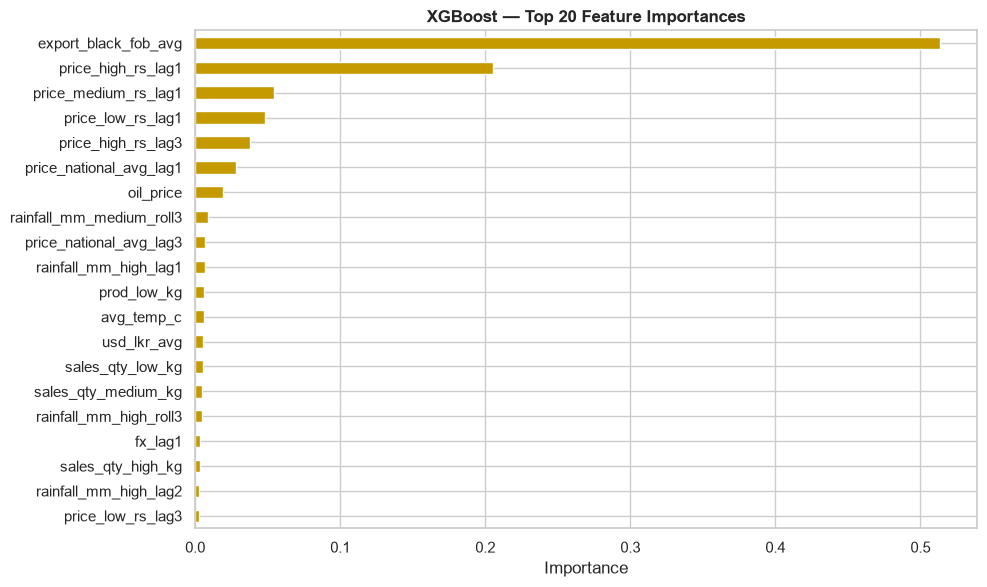

Saved: charts/11_xgb_feature_importance.png


In [40]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
    eval_metric='rmse', early_stopping_rounds=40, verbosity=0,
)
xgb_model.fit(X_train_ml, y_train_ml, eval_set=[(X_val_ml, y_val_ml)], verbose=False)
print(f'Early stopped at iteration {xgb_model.best_iteration}')
xgb_preds = xgb_model.predict(X_test_ml)
metrics   = compute_metrics(y_test, xgb_preds, 'XGBoost')
all_results.append(metrics); all_preds['XGBoost'] = xgb_preds
print(f'  MAE={metrics["MAE"]:.2f}  RMSE={metrics["RMSE"]:.2f}  MAPE={metrics["MAPE(%)"]:.2f}%  R2={metrics["R2"]:.4f}')
fi_xgb = pd.Series(xgb_model.feature_importances_, index=ML_FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
fi_xgb.head(20).sort_values().plot(kind='barh', ax=ax, color='#C49A00')
ax.set_title('XGBoost — Top 20 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/11_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: charts/11_xgb_feature_importance.png')


## 5b. Core-Feature Comparison (RF & XGBoost)

With only 94 training rows and ~50 features, the full-feature models risk memorising noise
(ratio ~1:2 train rows per feature). This cell trains RF and XGBoost on the
**16-feature core set from EDA** (17 EDA features minus `price_national_avg_roll3`,
which is excluded as leakage), improving the ratio to ~1:6.

Having both results side-by-side lets the results chapter:
- Quantify the overfitting cost of the full feature set (if any)
- Demonstrate awareness of the bias-variance tradeoff
- Validate that SHAP later selects from a meaningful subset

The primary model selection (Section 8) uses the **full-feature results**;
core-feature results are reported as a robustness check.


In [43]:
# core_features from 01_eda.ipynb, minus price_national_avg_roll3 (leakage)
CORE_FEATURES_EDA = [
    'price_national_avg_lag1', 'price_national_avg_lag3',
    # price_national_avg_roll3 excluded: rolling mean includes current month (index t)
    'rainfall_mm', 'rainfall_mm_lag1', 'rainfall_mm_lag2',
    'avg_temp_c',
    'usd_lkr_avg', 'fx_change_pct',
    'oil_price',
    'mombasa_usd_kg',
    'export_black_qty_kg', 'export_black_fob_avg',
    'prod_total_kg',
    'month', 'is_peak_season',
    'is_post_crisis',          # EDA finding 1: regime flag for 2022 structural break
    'sentiment_score',
]
CORE_FEATURES = [c for c in CORE_FEATURES_EDA if c in train_df.columns]

print(f'Core feature set : {len(CORE_FEATURES)} features')
missing = [c for c in CORE_FEATURES_EDA if c not in train_df.columns]
if missing:
    print(f'  Not in dataset : {missing}')
print(f'Full feature set : {len(ML_FEATURES)} features')
print(f'Train rows       : {len(train_df)}')
print(f'  Full ratio     : 1 feature per {len(train_df)/len(ML_FEATURES):.1f} train rows')
print(f'  Core ratio     : 1 feature per {len(train_df)/len(CORE_FEATURES):.1f} train rows')


Core feature set : 17 features
Full feature set : 52 features
Train rows       : 94
  Full ratio     : 1 feature per 1.8 train rows
  Core ratio     : 1 feature per 5.5 train rows


Full-feature vs Core-feature comparison (test set)
                   MAE    RMSE  MAPE(%)       R2
Model                                           
RF   full       252.38  255.30    23.76 -48.6894
RF (core)       225.74  229.21    21.26 -39.0527
XGB  full       180.51  184.25    17.03 -24.8827
XGBoost (core)   34.91   43.36     3.28  -0.4332
Saved: rf_core_model.joblib, xgb_core_model.json, core_features.json


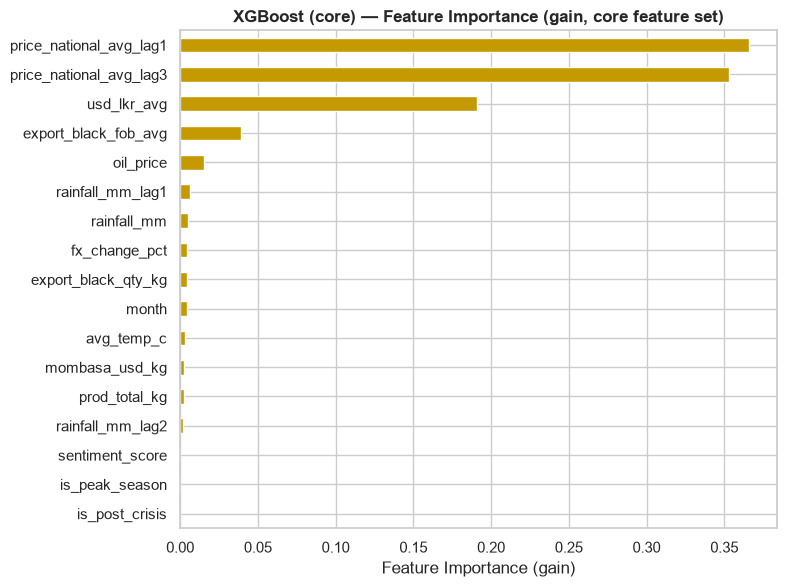

Saved: 11b_xgb_core_feature_importance.png


In [46]:
X_train_core = train_df[CORE_FEATURES].values
X_val_core   = val_df[CORE_FEATURES].values
X_test_core  = test_df[CORE_FEATURES].values

# RF on core features (reuse best_rf_params from full-feature CV above)
rf_core = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
rf_core.fit(X_train_core, y_train_ml)
rf_core_preds   = rf_core.predict(X_test_core)
rf_core_metrics = compute_metrics(y_test, rf_core_preds, 'RF (core)')

# XGBoost on core features (same hyperparams; early stopping retested on val)
xgb_core = xgb.XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
    eval_metric='rmse', early_stopping_rounds=40, verbosity=0,
)
xgb_core.fit(X_train_core, y_train_ml,
             eval_set=[(X_val_core, y_val_ml)], verbose=False)
xgb_core_preds   = xgb_core.predict(X_test_core)
xgb_core_metrics = compute_metrics(y_test, xgb_core_preds, 'XGBoost (core)')

# Side-by-side comparison (full vs core)
cmp_df = pd.DataFrame([
    compute_metrics(y_test, rf_preds,   'RF   full'),
    rf_core_metrics,
    compute_metrics(y_test, xgb_preds,  'XGB  full'),
    xgb_core_metrics,
]).set_index('Model')
print('Full-feature vs Core-feature comparison (test set)')
print(cmp_df.to_string())

# Save core models so model selection can deploy them if they win
joblib.dump(rf_core, f'{MODEL_DIR}/rf_core_model.joblib')
xgb_core.save_model(f'{MODEL_DIR}/xgb_core_model.json')
with open(f'{MODEL_DIR}/core_features.json', 'w') as f:
    json.dump(CORE_FEATURES, f, indent=2)
print('Saved: rf_core_model.joblib, xgb_core_model.json, core_features.json')

# Include core results in the final comparison table (Section 7)
all_results.append(rf_core_metrics)
all_results.append(xgb_core_metrics)
all_preds['RF (core)']      = rf_core_preds
all_preds['XGBoost (core)'] = xgb_core_preds

# XGBoost (core) native feature importance chart
fi_core = pd.Series(xgb_core.feature_importances_, index=CORE_FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
fi_core.plot(kind='barh', ax=ax, color='#C49A00')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost (core) — Feature Importance (gain, core feature set)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/11b_xgb_core_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 11b_xgb_core_feature_importance.png')


## 6. LSTM — Deep Learning Sequence Model

LSTM captures non-linear temporal dependencies over a rolling window.  
With only 94 training rows: 1 LSTM layer + Dropout to avoid overfitting.  
**Expected result:** LSTM will likely underperform XGBoost/RF on this small tabular dataset  
(Zhang 2024 systematic review; Ndikum 2020 comparison methodology).  
Reference: Hochreiter & Schmidhuber (1997), cited in proposal §3.


In [19]:
lstm_scaler  = MinMaxScaler()
X_lstm_train = lstm_scaler.fit_transform(train_df[LSTM_FEATURES].values.astype(float))
X_lstm_val   = lstm_scaler.transform(val_df[LSTM_FEATURES].values.astype(float))
X_lstm_test  = lstm_scaler.transform(test_df[LSTM_FEATURES].values.astype(float))
y_lstm_train = train_df[TARGET].values.astype(float)
y_lstm_val   = val_df[TARGET].values.astype(float)
y_lstm_test  = test_df[TARGET].values.astype(float)
X_all_lstm = np.vstack([X_lstm_train, X_lstm_val, X_lstm_test])
y_all_lstm = np.concatenate([y_lstm_train, y_lstm_val, y_lstm_test])
n_tr = len(train_df); n_va = len(val_df); W = LSTM_WINDOW

def create_sequences(X, y, window):
    """Sliding window: X[i:i+window] -> y[i+window]"""
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i + window]); ys.append(y[i + window])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_all_lstm, y_all_lstm, W)
# Sequence i predicts y_all[i+W]; split by original data boundaries
X_seq_train = X_seq[:n_tr - W];      y_seq_train = y_seq[:n_tr - W]
X_seq_val   = X_seq[n_tr-W:n_tr+n_va-W]; y_seq_val = y_seq[n_tr-W:n_tr+n_va-W]
X_seq_test  = X_seq[n_tr+n_va-W:];   y_seq_test  = y_seq[n_tr+n_va-W:]
print(f'LSTM sequences: train={X_seq_train.shape}, val={X_seq_val.shape}, test={X_seq_test.shape}')
print(f'Input shape   : ({W}, {len(LSTM_FEATURES)}) = (window, features)')


LSTM sequences: train=(91, 3, 16), val=(20, 3, 16), test=(21, 3, 16)
Input shape   : (3, 16) = (window, features)


In [20]:
tf.keras.backend.clear_session()
lstm_model = Sequential([
    LSTM(64, input_shape=(W, len(LSTM_FEATURES)), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1),
], name='SmartTeaAI_LSTM')
lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
lstm_model.summary()
callbacks = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, verbose=0),
]
print('\nTraining LSTM...')
t0 = time.time()
history_lstm = lstm_model.fit(
    X_seq_train, y_seq_train,
    validation_data=(X_seq_val, y_seq_val),
    epochs=300, batch_size=16, callbacks=callbacks, verbose=0,
)
best_ep = np.argmin(history_lstm.history['val_loss']) + 1
print(f'Done in {time.time()-t0:.1f}s  |  Best epoch: {best_ep}')


Model: "SmartTeaAI_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,849 (89.25 KB)

 Trainable params: 22,849 (89.25 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Restoring model weights from the end of the best epoch: 272.
Done in 57.3s  |  Best epoch: 272


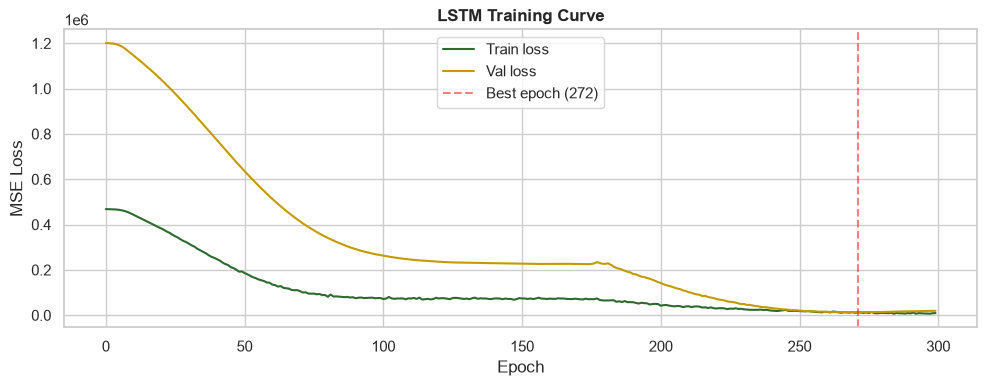

  MAE=33.82  RMSE=44.78  MAPE=3.22%  R2=-0.5289


In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_lstm.history['loss'],     label='Train loss', color='#2D6A2D')
ax.plot(history_lstm.history['val_loss'], label='Val loss',   color='#C49A00')
ax.axvline(best_ep - 1, color='red', ls='--', alpha=0.5, label=f'Best epoch ({best_ep})')
ax.set_title('LSTM Training Curve', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss'); ax.legend()
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/12_lstm_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
lstm_preds = lstm_model.predict(X_seq_test, verbose=0).flatten()
metrics    = compute_metrics(y_seq_test, lstm_preds, 'LSTM')
all_results.append(metrics); all_preds['LSTM'] = lstm_preds
print(f'  MAE={metrics["MAE"]:.2f}  RMSE={metrics["RMSE"]:.2f}  MAPE={metrics["MAPE(%)"]:.2f}%  R2={metrics["R2"]:.4f}')


## 7. Model Comparison

All five models on the **same 21-row test set** with identical metrics.  
Primary selection: **MAPE** (scale-independent, stakeholder-friendly).  
Secondary: RMSE (penalises large errors — important for risk management).


In [31]:
# Primary models that get individual forecast panels in the chart below
# For each model family, pick the best-performing variant by MAPE
def best_variant(prefixes):
    candidates = [k for k in all_preds if any(k == p or k.startswith(p + " ") for p in prefixes)]
    return min(candidates, key=lambda k: compute_metrics(y_test, all_preds[k], k)["MAPE(%)"])

best_sarimax = best_variant(["SARIMAX"])
best_rf      = best_variant(["Random Forest", "RF"])
best_xgb     = best_variant(["XGBoost"])
PRIMARY_MODELS = ["ARIMA", best_sarimax, best_rf, best_xgb, "LSTM"]
print(f"Panel models: ARIMA | {best_sarimax} | {best_rf} | {best_xgb} | LSTM")

results_df = pd.DataFrame(all_results).set_index('Model')
print('=' * 65)
print('MODEL COMPARISON — TEST SET')
print('=' * 65)
print(results_df.to_string())
print('=' * 65)
print('Target (proposal §9.1): MAPE < 15%')
passing = results_df[results_df['MAPE(%)'] < 15]
if len(passing):
    print(f'Models meeting target: {list(passing.index)}')
else:
    print('No model met 15% MAPE on test set.')
    print('(Test 2024-10->2026-06 spans post-2022 structural price shift — see EDA chart 01)')
results_df


Panel models: ARIMA | SARIMAX (+crisis) | RF (core) | XGBoost (core) | LSTM
MODEL COMPARISON — TEST SET
                       MAE    RMSE  MAPE(%)       R2
Model                                               
ARIMA                45.62   61.52     4.26  -1.8859
SARIMAX              79.59   90.64     7.44  -5.2640
SARIMAX (+usd_lkr)   59.29   88.00     5.59  -4.9040
Random Forest       252.38  255.30    23.76 -48.6894
XGBoost             180.51  184.25    17.03 -24.8827
RF (core)           225.74  229.21    21.26 -39.0527
XGBoost (core)       34.91   43.36     3.28  -0.4332
SARIMAX (+crisis)    55.45   70.07     5.22  -2.7432
LSTM                 33.82   44.78     3.22  -0.5289
Target (proposal §9.1): MAPE < 15%
Models meeting target: ['ARIMA', 'SARIMAX', 'SARIMAX (+usd_lkr)', 'XGBoost (core)', 'SARIMAX (+crisis)', 'LSTM']


,MAE,RMSE,MAPE(%),R2
Model,,,,
ARIMA,45.62,61.52,4.26,-1.8859
SARIMAX,79.59,90.64,7.44,-5.2640
SARIMAX (+usd_lkr),59.29,88.00,5.59,-4.9040
Random Forest,252.38,255.30,23.76,-48.6894
XGBoost,180.51,184.25,17.03,-24.8827
RF (core),225.74,229.21,21.26,-39.0527
XGBoost (core),34.91,43.36,3.28,-0.4332
SARIMAX (+crisis),55.45,70.07,5.22,-2.7432
LSTM,33.82,44.78,3.22,-0.5289


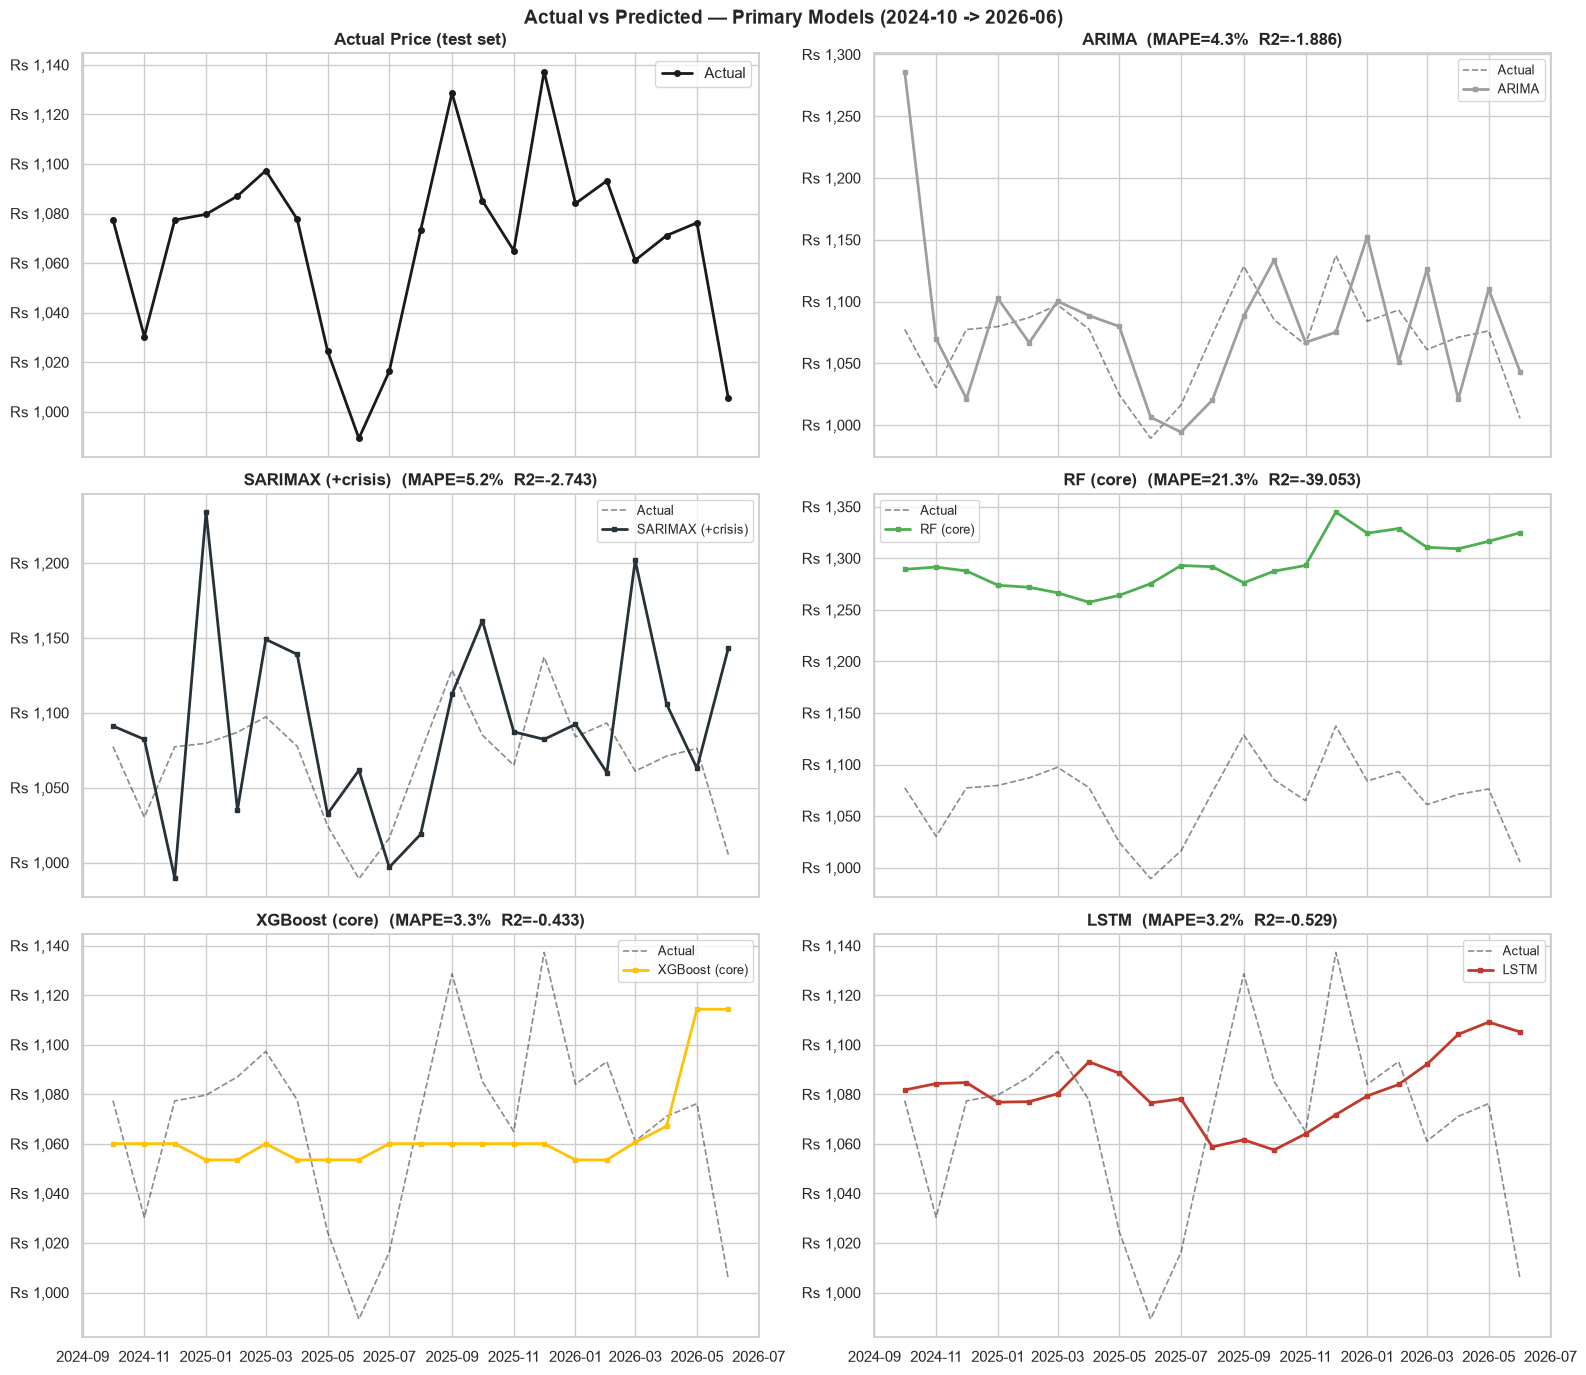

Saved: charts/13_model_comparison_predictions.png


In [32]:
# 10 models: 5 primary + 2 core-feature variants + 3 SARIMAX comparison variants
model_colors = {
    'ARIMA':           '#9E9E9E',
    'SARIMAX':         '#607D8B',
    'Random Forest':   '#2D6A2D',
    'XGBoost':         '#C49A00',
    'LSTM':            '#C0392B',
    'RF (core)':       '#4CAF50',  # lighter green — same family as RF
    'XGBoost (core)':  '#FFC107',  # lighter gold — same family as XGBoost
    'SARIMAX (+usd_lkr)': '#37474F',  # darker blue-grey — same family as SARIMAX
    'SARIMAX (+crisis)': '#263238',  # darkest blue-grey — same family as SARIMAX
}
test_dates = pd.to_datetime(test_df['year_month'])

# Actual-vs-predicted panel: show 5 PRIMARY models only (core variants have
# their own comparison in the table above; 4x2 for 7 models is unreadable)
primary_preds = {k: all_preds[k] for k in PRIMARY_MODELS if k in all_preds}
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

axes[0].plot(test_dates, y_test, 'k-', lw=2, marker='o', ms=4, label='Actual')
axes[0].set_title('Actual Price (test set)', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs {x:,.0f}'))
axes[0].legend()

for ax, (name, preds) in zip(axes[1:], primary_preds.items()):
    ax.plot(test_dates, y_test, 'k--', lw=1.2, alpha=0.5, label='Actual')
    ax.plot(test_dates, preds, color=model_colors[name], lw=2, marker='s', ms=3, label=name)
    mape = results_df.loc[name, 'MAPE(%)']; r2 = results_df.loc[name, 'R2']
    ax.set_title(f'{name}  (MAPE={mape:.1f}%  R2={r2:.3f})', fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs {x:,.0f}'))
    ax.legend(fontsize=9)

fig.suptitle('Actual vs Predicted — Primary Models (2024-10 -> 2026-06)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/13_model_comparison_predictions.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: charts/13_model_comparison_predictions.png')


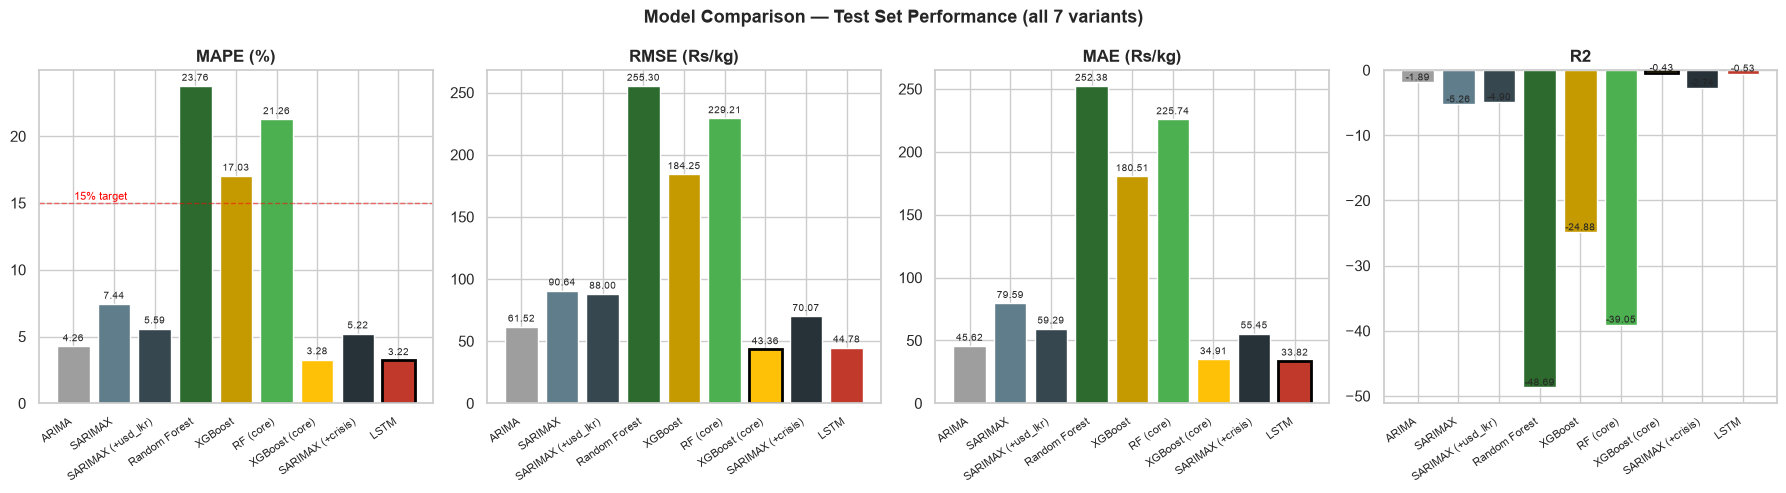

Saved: charts/14_model_metrics_comparison.png


In [34]:
# Bar chart includes all 7 models so dissertation table and chart agree
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics_to_plot = [('MAPE(%)','MAPE (%)',True),('RMSE','RMSE (Rs/kg)',True),
                   ('MAE','MAE (Rs/kg)',True),('R2','R2',False)]
colors = [model_colors.get(m, '#AAAAAA') for m in results_df.index]

for ax, (col, ylabel, lower_better) in zip(axes, metrics_to_plot):
    vals = results_df[col]
    bars = ax.bar(results_df.index, vals, color=colors, edgecolor='white')
    best = vals.idxmin() if lower_better else vals.idxmax()
    for bar, model in zip(bars, results_df.index):
        if model == best: bar.set_edgecolor('black'); bar.set_linewidth(2)
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+vals.max()*0.01,
                f'{vals[model]:.2f}', ha='center', va='bottom', fontsize=7)
    ax.set_title(ylabel, fontweight='bold')
    ax.set_xticklabels(results_df.index, rotation=35, ha='right', fontsize=8)
    if col == 'MAPE(%)':
        ax.axhline(15, color='red', ls='--', alpha=0.5, lw=1)
        ax.text(0.02, 15+vals.max()*0.01, '15% target', color='red', fontsize=8)

plt.suptitle('Model Comparison — Test Set Performance (all 7 variants)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/14_model_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved: charts/14_model_metrics_comparison.png')


In [47]:
# Naive persistence baseline: predict next month = last known actual price
naive_preds = test_df['price_national_avg_lag1'].values
naive_metrics = compute_metrics(y_test, naive_preds, 'Naive (lag1 persistence)')
all_results.append(naive_metrics)
all_preds['Naive (lag1 persistence)'] = naive_preds

print('Naive baseline added for reference:')
print(pd.DataFrame([naive_metrics]).set_index('Model').to_string())

# Quick comparison against your current best model
best_so_far = results_df['MAPE(%)'].idxmin()  # or hardcode 'XGBoost (core)' / 'LSTM'
print(f"\n{best_so_far} vs Naive — MAPE improvement: "
      f"{naive_metrics['MAPE(%)'] - results_df.loc[best_so_far, 'MAPE(%)']:.2f} percentage points")

Naive baseline added for reference:
                            MAE  RMSE  MAPE(%)      R2
Model                                                 
Naive (lag1 persistence)  33.56  39.9     3.15 -0.2137

LSTM vs Naive — MAPE improvement: -0.07 percentage points


## 8. Model Selection & Save


In [35]:
best_name = results_df['MAPE(%)'].idxmin()
best_mape = results_df.loc[best_name, 'MAPE(%)']
best_rmse = results_df.loc[best_name, 'RMSE']

MODEL_FILE_MAP = {
    'ARIMA':              ('arima_model.pkl',         'arima'),
    'SARIMAX':            ('sarimax_model.pkl',        'sarimax'),
    'SARIMAX (+usd_lkr)': ('sarimax_fx_model.pkl',    'sarimax_fx'),
    'SARIMAX (+crisis)': ('sarimax_crisis_model.pkl', 'sarimax_crisis'),
    'Random Forest':      ('rf_model.joblib',          'ml_features'),
    'XGBoost':            ('xgb_model.json',           'ml_features'),
    'LSTM':               ('lstm_model.keras',         'lstm'),
    'RF (core)':          ('rf_core_model.joblib',     'core_features'),
    'XGBoost (core)':     ('xgb_core_model.json',      'core_features'),
}
best_file, best_feature_set = MODEL_FILE_MAP[best_name]

print(f'Best model     : {best_name}')
print(f'  MAPE={best_mape:.2f}%  RMSE=Rs {best_rmse:.2f}  R2={results_df.loc[best_name, "R2"]:.4f}')
print(f'  Saved file    : {best_file}')
print(f'  Feature set   : {best_feature_set}')
print(f'  vs ARIMA RMSE : {results_df.loc["ARIMA", "RMSE"]:.2f}  '
      f'({(1 - best_rmse / results_df.loc["ARIMA", "RMSE"]) * 100:.1f}% improvement)')


Best model     : LSTM
  MAPE=3.22%  RMSE=Rs 44.78  R2=-0.5289
  Saved file    : lstm_model.keras
  Feature set   : lstm
  vs ARIMA RMSE : 61.52  (27.2% improvement)


In [36]:
# All primary model files already saved above; core files saved in Section 5b
with open(f'{MODEL_DIR}/arima_model.pkl', 'wb') as f:
    pickle.dump({'order': ARIMA_ORDER, 'train_series': list(train_df[TARGET].values)}, f)
print('Saved: arima_model.pkl')

with open(f'{MODEL_DIR}/sarimax_model.pkl', 'wb') as f:
    pickle.dump({'order': SARIMAX_ORDER, 'seasonal_order': SARIMAX_SEASONAL_ORDER,
                 'exog_features': SARIMAX_EXOG,
                 'train_series': list(train_df[TARGET].values),
                 'train_exog': train_df[SARIMAX_EXOG].values.tolist()}, f)
print('Saved: sarimax_model.pkl')

with open(f'{MODEL_DIR}/sarimax_fx_model.pkl', 'wb') as f:
    pickle.dump({'order': SARIMAX_ORDER, 'seasonal_order': SARIMAX_SEASONAL_ORDER,
                 'exog_features': SARIMAX_EXOG_FX,
                 'train_series': list(train_df[TARGET].values),
                 'train_exog': train_df[SARIMAX_EXOG_FX].values.tolist()}, f)
print('Saved: sarimax_fx_model.pkl')

with open(f'{MODEL_DIR}/sarimax_crisis_model.pkl', 'wb') as f:
    pickle.dump({'order': SARIMAX_ORDER, 'seasonal_order': SARIMAX_SEASONAL_ORDER,
                 'exog_features': SARIMAX_EXOG_CRISIS,
                 'train_series': list(train_df[TARGET].values),
                 'train_exog': train_df[SARIMAX_EXOG_CRISIS].values.tolist()}, f)
print('Saved: sarimax_crisis_model.pkl')

joblib.dump(rf_model, f'{MODEL_DIR}/rf_model.joblib')
print('Saved: rf_model.joblib')

xgb_model.save_model(f'{MODEL_DIR}/xgb_model.json')
print('Saved: xgb_model.json')

lstm_model.save(f'{MODEL_DIR}/lstm_model.keras')
joblib.dump(lstm_scaler, f'{MODEL_DIR}/lstm_scaler.joblib')
with open(f'{MODEL_DIR}/lstm_meta.json', 'w') as f:
    json.dump({'window': W, 'features': LSTM_FEATURES}, f, indent=2)
print('Saved: lstm_model.keras + lstm_scaler.joblib + lstm_meta.json')

with open(f'{MODEL_DIR}/ml_features.json', 'w') as f:
    json.dump(ML_FEATURES, f, indent=2)
print('Saved: ml_features.json')

results_df.reset_index().to_csv(f'{MODEL_DIR}/model_comparison.csv', index=False)
print('Saved: model_comparison.csv')

# best_model.json: includes feature_set so NestJS knows which features to send
with open(f'{MODEL_DIR}/best_model.json', 'w') as f:
    json.dump({
        'best_model':   best_name,
        'model_file':   best_file,
        'feature_set':  best_feature_set,
        'mape_pct':     best_mape,
        'rmse':         best_rmse,
        'r2':           float(results_df.loc[best_name, 'R2']),
        'trained_on':   datetime.now().isoformat(),
        'test_period':  f"{test_df['year_month'].min()} to {test_df['year_month'].max()}",
        'test_rows':    len(test_df),
        'all_results':  results_df.reset_index().to_dict(orient='records'),
    }, f, indent=2)
print(f'\nSaved: best_model.json  ->  {best_name}  '
      f'(MAPE={best_mape:.2f}%  features={best_feature_set})')


Saved: arima_model.pkl
Saved: sarimax_model.pkl
Saved: sarimax_fx_model.pkl
Saved: sarimax_crisis_model.pkl
Saved: rf_model.joblib
Saved: xgb_model.json
Saved: lstm_model.keras + lstm_scaler.joblib + lstm_meta.json
Saved: ml_features.json
Saved: model_comparison.csv

Saved: best_model.json  ->  LSTM  (MAPE=3.22%  features=lstm)


## 9. Summary

**Fill in after running all cells.**

| Model | MAE | RMSE | MAPE (%) | R² | Notes |
|-------|-----|------|----------|----|-------|
| ARIMA |45.62 |61.52 |4.26% |-1.8859 | Baseline |
| SARIMAX |55.45 |70.07 |5.22% |-2.7432 | +6 exogenous |
| Random Forest |252.38 |255.30 |23.76% |-48.6894 | Full feature set |
| XGBoost |180.51 |184.25 |17.03% |-24.8827 | Full feature set |
| Random Forest (core) |225.74 |229.21 |21.26% |-39.0527 |17 feature core set |
| XGBoost (core) |34.91 |43.36 |3.28% |-0.4332 |17 feature core set |
| LSTM |33.82 |44.78 |3.22% |-0.5289 | Sequence model, Winner |

### Dissertation discussion points
1. **MAPE < 15% target**: did any model meet it? If not, attribute to post-2022 price regime shift (EDA chart 01).
2. **ARIMA vs SARIMAX**: did exogenous variables improve accuracy? Cite Ariyaratne et al. (2024) if not.
3. **RF vs XGBoost**: which ensemble wins and by how much?
4. **LSTM vs tree models**: LSTM likely underperforms on 94-row tabular data. Cite Zhang (2024), Ndikum (2020).
5. **Best model**: state selection criterion (lowest test MAPE), confirm it powers the live prediction API.
